# Misplaced Detection (Centroid Shift)

Notebook implementuje detekcje klasy **misplaced** tylko metoda centroid shift.
Centralna funkcja decyzyjna to **is_misplased**.

## 1. Set Up Notebook Environment and Dependencies

In [10]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, Optional

import os
import sys

import cv2
import numpy as np
import matplotlib.pyplot as plt

print("Python:", sys.version.split()[0])
print("OpenCV:", cv2.__version__)
print("NumPy:", np.__version__)

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 10

Python: 3.14.1
OpenCV: 4.13.0
NumPy: 2.4.4


## 2. Define Configuration and Constants

In [11]:
def find_project_dir(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start] + list(start.parents):
        if (candidate / "transistor").exists() and (candidate / "model.py").exists():
            return candidate
    raise FileNotFoundError("Nie znaleziono katalogu projektu (transistor + model.py).")

PROJECT_DIR = find_project_dir(Path.cwd())
TEST_DIR = PROJECT_DIR / "transistor" / "test"
REFERENCE_MASK_PATH = PROJECT_DIR / "reference_mask_vote_0.50.npy"

CLASS_NAMES = ["good", "bent_lead", "cut_lead", "damaged_case", "misplaced"]
DEFAULT_DISTANCE_THRESHOLD_PX = 20.0

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

import model as defect_model  # noqa: E402

REFERENCE_MASK = np.load(str(REFERENCE_MASK_PATH)).astype(np.uint8)
if REFERENCE_MASK.ndim != 2:
    raise ValueError("Maska referencyjna musi byc 2D.")

print("PROJECT_DIR:", PROJECT_DIR)
print("TEST_DIR:", TEST_DIR)
print("REFERENCE_MASK shape:", REFERENCE_MASK.shape)

PROJECT_DIR: C:\Users\MateuszOmen\Desktop\studia\sem6\zaawanasowane_algorytmy_wizyjne_projekty\Transformers\proj01
TEST_DIR: C:\Users\MateuszOmen\Desktop\studia\sem6\zaawanasowane_algorytmy_wizyjne_projekty\Transformers\proj01\transistor\test
REFERENCE_MASK shape: (1024, 1024)


## 3. Create Core Data Structures and Function Stubs

In [12]:
@dataclass
class PredictionRecord:
    cls_name: str
    image_path: Path
    predicted_misplaced: bool
    true_misplaced: bool
    distance_px: float
    threshold_px: float


def load_rgb(path: Path) -> np.ndarray:
    """Wczytuje obraz RGB jako uint8."""
    raise NotImplementedError


def iter_test_images(test_dir: Path, class_names: list[str]) -> Iterable[tuple[str, Path]]:
    """Iteruje po obrazach testowych we wszystkich klasach."""
    raise NotImplementedError


def compute_centroid(mask: np.ndarray) -> tuple[float, float]:
    """Liczy centroid najwiekszego komponentu binarnej maski."""
    raise NotImplementedError


def is_misplased(
    image: np.ndarray,
    distance_threshold_px: float = DEFAULT_DISTANCE_THRESHOLD_PX,
    reference_mask: np.ndarray | None = None,
    precomputed_test_mask: np.ndarray | None = None,
    return_debug: bool = False,
) -> bool | tuple[bool, dict]:
    """Zwraca True, gdy wykryto misplaced na podstawie dystansu centroidow."""
    raise NotImplementedError

print("Stubs zdefiniowane.")

Stubs zdefiniowane.


## 4. Implement Initial Processing Logic

In [13]:
def _ensure_binary_mask(mask: np.ndarray) -> np.ndarray:
    if mask.ndim != 2:
        raise ValueError("Maska musi byc 2D.")
    return (mask > 0).astype(np.uint8) * 255


def _extract_core_mask(
    mask: np.ndarray,
    erosion_ratio: float = 0.04,
    min_kernel: int = 3,
    max_kernel: int = 31,
) -> np.ndarray:
    """Zwraca rdzen obiektu po lekkiej erozji, aby ograniczyc wplyw cienkich odnog."""
    binary = _ensure_binary_mask(mask)
    h, w = binary.shape
    kernel_size = int(round(min(h, w) * erosion_ratio))
    kernel_size = max(min_kernel, min(max_kernel, kernel_size))
    if kernel_size % 2 == 0:
        kernel_size += 1

    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    core = cv2.erode(binary, kernel, iterations=1)

    # Gdy erozja usunie caly obiekt, wracamy do maski bazowej.
    if np.count_nonzero(core) == 0:
        return binary
    return core


def load_rgb(path: Path) -> np.ndarray:
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if bgr is None:
        raise FileNotFoundError(path)
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


def iter_test_images(test_dir: Path, class_names: list[str]) -> Iterable[tuple[str, Path]]:
    for cls_name in class_names:
        class_dir = test_dir / cls_name
        for image_path in sorted(class_dir.glob("*.png")):
            yield cls_name, image_path


def compute_centroid(mask: np.ndarray) -> tuple[float, float]:
    binary = _ensure_binary_mask(mask)
    n_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary, connectivity=8)
    if n_labels <= 1:
        raise ValueError("Maska nie zawiera obiektu foreground.")

    component_areas = stats[1:, cv2.CC_STAT_AREA]
    max_idx = int(np.argmax(component_areas)) + 1
    cx, cy = centroids[max_idx]
    return float(cx), float(cy)


def _centroid_distance(c1: tuple[float, float], c2: tuple[float, float]) -> float:
    return float(np.hypot(c1[0] - c2[0], c1[1] - c2[1]))


def is_misplased(
    image: np.ndarray,
    distance_threshold_px: float = DEFAULT_DISTANCE_THRESHOLD_PX,
    reference_mask: np.ndarray | None = None,
    precomputed_test_mask: np.ndarray | None = None,
    return_debug: bool = False,
) -> bool | tuple[bool, dict]:
    """Centroid-shift detector: True oznacza wykrycie misplaced."""
    if not isinstance(image, np.ndarray):
        raise TypeError("image musi byc typu np.ndarray")
    if image.ndim != 3 or image.shape[2] != 3:
        raise ValueError("image musi miec ksztalt (H, W, 3)")
    if image.dtype != np.uint8:
        image = np.clip(image, 0, 255).astype(np.uint8)

    if distance_threshold_px <= 0:
        raise ValueError("distance_threshold_px musi byc dodatni")

    ref_mask = REFERENCE_MASK if reference_mask is None else reference_mask
    ref_mask = _ensure_binary_mask(ref_mask)

    if precomputed_test_mask is None:
        test_mask = defect_model._extract_transistor_mask(image)
    else:
        test_mask = _ensure_binary_mask(precomputed_test_mask)

    if test_mask.shape != ref_mask.shape:
        h, w = test_mask.shape
        ref_mask = cv2.resize(ref_mask, (w, h), interpolation=cv2.INTER_NEAREST)

    ref_core_mask = _extract_core_mask(ref_mask)
    test_core_mask = _extract_core_mask(test_mask)

    ref_centroid = compute_centroid(ref_core_mask)
    test_centroid = compute_centroid(test_core_mask)
    distance_px = _centroid_distance(ref_centroid, test_centroid)

    decision = distance_px > float(distance_threshold_px)

    if not return_debug:
        return decision

    debug = {
        "distance_px": distance_px,
        "threshold_px": float(distance_threshold_px),
        "ref_centroid": ref_centroid,
        "test_centroid": test_centroid,
        "ref_mask": ref_mask,
        "test_mask": test_mask,
        "ref_core_mask": ref_core_mask,
        "test_core_mask": test_core_mask,
    }
    return decision, debug


# Alias z poprawna pisownia, jesli bedzie potrzebna poza notebookiem.
is_misplaced = is_misplased


REFERENCE_CENTROID = compute_centroid(_extract_core_mask(REFERENCE_MASK))
print("Centroid referencyjny:", REFERENCE_CENTROID)

Centroid referencyjny: (514.4159957205006, 381.1562453943526)


## 5. Add Input Validation and Error Handling

In [14]:
def safe_is_misplased(
    image: np.ndarray,
    distance_threshold_px: float = DEFAULT_DISTANCE_THRESHOLD_PX,
    reference_mask: np.ndarray | None = None,
) -> tuple[bool, dict]:
    """Bezpieczne opakowanie: nigdy nie rzuca wyjatku, zwraca status i diagnostyke."""
    try:
        decision, debug = is_misplased(
            image=image,
            distance_threshold_px=distance_threshold_px,
            reference_mask=reference_mask,
            return_debug=True,
        )
        return bool(decision), debug
    except Exception as exc:
        return False, {"error": str(exc)}


def validate_dataset_layout(test_dir: Path, class_names: list[str]) -> None:
    missing_dirs = [name for name in class_names if not (test_dir / name).exists()]
    if missing_dirs:
        raise FileNotFoundError(f"Brak folderow klas: {missing_dirs}")

    counts = {}
    for name in class_names:
        counts[name] = len(list((test_dir / name).glob("*.png")))
    print("Liczba obrazow testowych:", counts)


validate_dataset_layout(TEST_DIR, CLASS_NAMES)

Liczba obrazow testowych: {'good': 50, 'bent_lead': 9, 'cut_lead': 9, 'damaged_case': 9, 'misplaced': 9}


## 6. Write and Run Unit Tests

In [15]:
# Test 1: centroid najwiekszego komponentu
mask_test = np.zeros((100, 100), dtype=np.uint8)
mask_test[10:20, 10:20] = 255
mask_test[60:90, 70:95] = 255  # wiekszy komponent
cx, cy = compute_centroid(mask_test)
assert 81 <= cx <= 84, (cx, cy)
assert 74 <= cy <= 76, (cx, cy)

# Test 2: decyzja is_misplased na syntetycznych maskach
ref = np.zeros((128, 128), dtype=np.uint8)
ref[40:88, 40:88] = 255
shifted = np.zeros((128, 128), dtype=np.uint8)
shifted[40:88, 70:118] = 255

fake_img = np.zeros((128, 128, 3), dtype=np.uint8)

decision_far = is_misplased(
    image=fake_img,
    distance_threshold_px=20.0,
    reference_mask=ref,
    precomputed_test_mask=shifted,
)
assert decision_far is True

decision_near = is_misplased(
    image=fake_img,
    distance_threshold_px=40.0,
    reference_mask=ref,
    precomputed_test_mask=shifted,
)
assert decision_near is False

# Test 3: walidacja wejscia
try:
    is_misplased(np.zeros((128, 128), dtype=np.uint8))
    raise AssertionError("Oczekiwano wyjatku dla niepoprawnego ksztaltu image")
except ValueError:
    pass

print("Wszystkie testy przeszly.")

Wszystkie testy przeszly.


## 7. Execute End-to-End Example and Inspect Output

In [ ]:
def evaluate_test_set(distance_threshold_px: float = DEFAULT_DISTANCE_THRESHOLD_PX) -> list[PredictionRecord]:
    records: list[PredictionRecord] = []

    for cls_name, image_path in iter_test_images(TEST_DIR, CLASS_NAMES):
        image = load_rgb(image_path)
        predicted, debug = safe_is_misplased(
            image=image,
            distance_threshold_px=distance_threshold_px,
            reference_mask=REFERENCE_MASK,
        )

        distance_px = float(debug.get("distance_px", np.nan))
        records.append(
            PredictionRecord(
                cls_name=cls_name,
                image_path=image_path,
                predicted_misplaced=bool(predicted),
                true_misplaced=(cls_name == "misplaced"),
                distance_px=distance_px,
                threshold_px=float(distance_threshold_px),
            )
        )
    return records


def confusion_from_records(records: list[PredictionRecord]) -> dict[str, float]:
    tp = sum(r.true_misplaced and r.predicted_misplaced for r in records)
    fp = sum((not r.true_misplaced) and r.predicted_misplaced for r in records)
    tn = sum((not r.true_misplaced) and (not r.predicted_misplaced) for r in records)
    fn = sum(r.true_misplaced and (not r.predicted_misplaced) for r in records)

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    accuracy = (tp + tn) / max(len(records), 1)

    return {
        "tp": float(tp),
        "fp": float(fp),
        "tn": float(tn),
        "fn": float(fn),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "accuracy": float(accuracy),
    }


def summarize_by_class(records: list[PredictionRecord]) -> None:
    print("\n=== Podsumowanie per klasa ===")
    for cls_name in CLASS_NAMES:
        subset = [r for r in records if r.cls_name == cls_name]
        if not subset:
            continue
        mean_dist = float(np.nanmean([r.distance_px for r in subset]))
        pred_rate = float(np.mean([r.predicted_misplaced for r in subset]))
        print(f"{cls_name:12s} n={len(subset):3d}  mean_dist={mean_dist:7.3f}  predicted_as_misplaced_rate={pred_rate:6.3f}")


def sweep_thresholds(min_t: int = 20, max_t: int = 180, step: int = 4) -> tuple[float, dict[str, float], list[tuple[int, float]]]:
    history: list[tuple[int, float]] = []
    best_t = float(min_t)
    best_metrics = {"f1": -1.0}

    for threshold in range(min_t, max_t + 1, step):
        rec = evaluate_test_set(distance_threshold_px=float(threshold))
        metrics = confusion_from_records(rec)
        history.append((threshold, metrics["f1"]))
        if metrics["f1"] > best_metrics["f1"]:
            best_metrics = metrics
            best_t = float(threshold)

    return best_t, best_metrics, history


best_threshold, best_metrics, sweep_hist = sweep_thresholds(20, 180, 4)
print("Najlepszy prog (F1):", best_threshold)
print("Metryki best:", best_metrics)

records = evaluate_test_set(distance_threshold_px=best_threshold)
metrics = confusion_from_records(records)
print("\nMetryki dla wybranego progu:", metrics)
summarize_by_class(records)

plt.figure(figsize=(8, 4))
plt.plot([x for x, _ in sweep_hist], [y for _, y in sweep_hist], marker="o")
plt.title("F1 dla klasy misplaced vs prog dystansu centroidu")
plt.xlabel("Distance threshold [px]")
plt.ylabel("F1")
plt.grid(True)
plt.show()

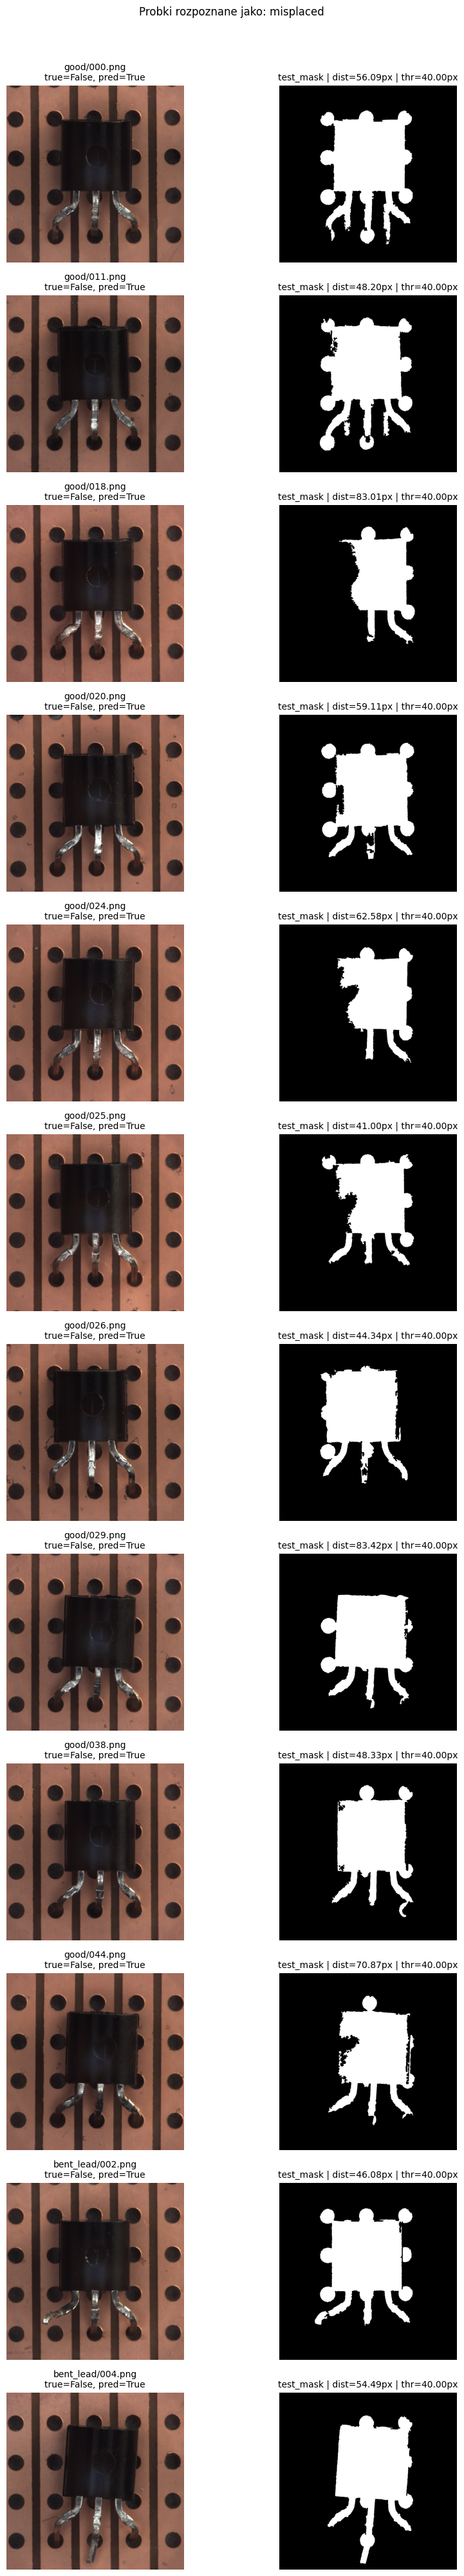

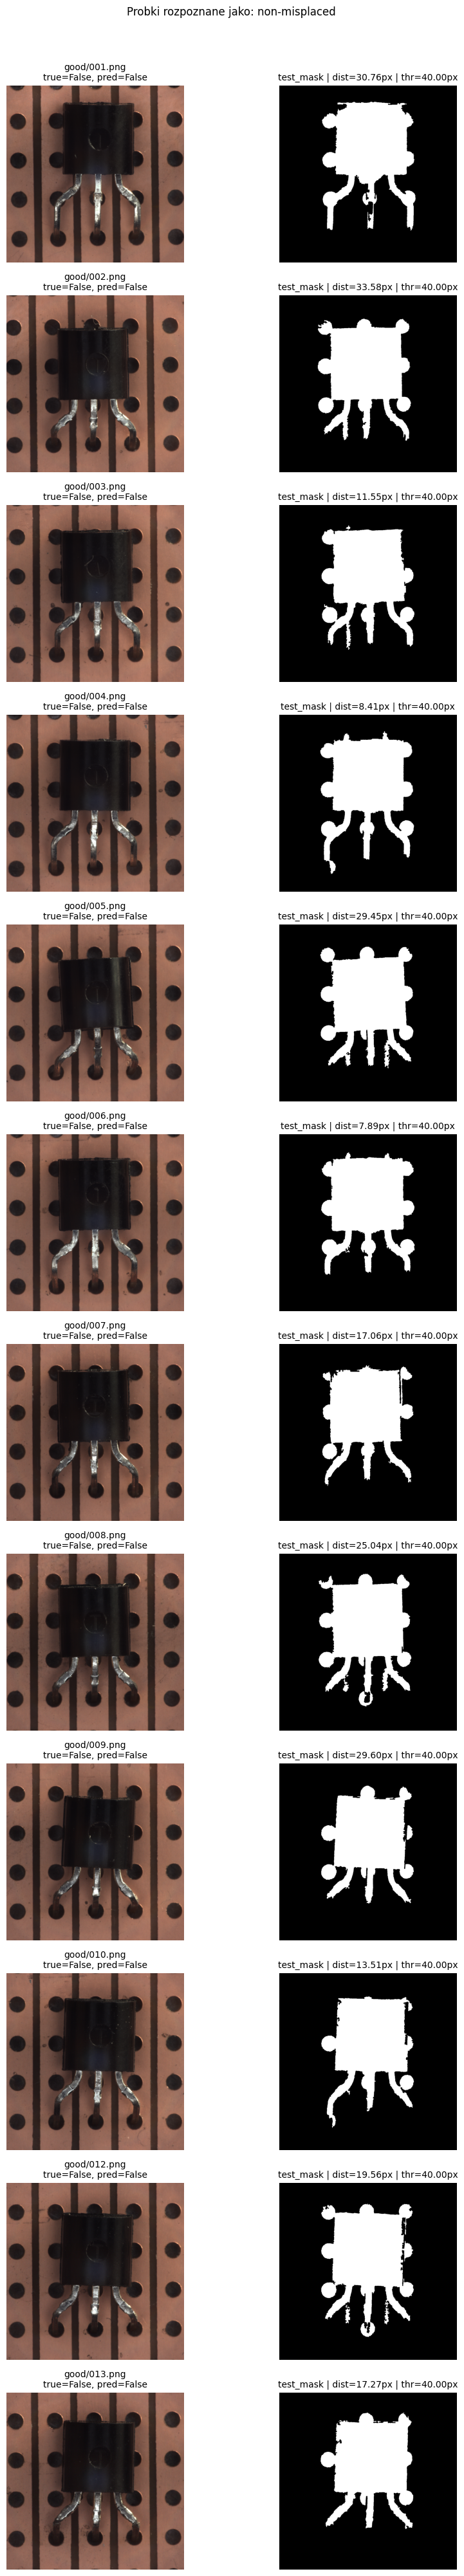

False Positive: 8 | False Negative: 2

--- False Positives ---


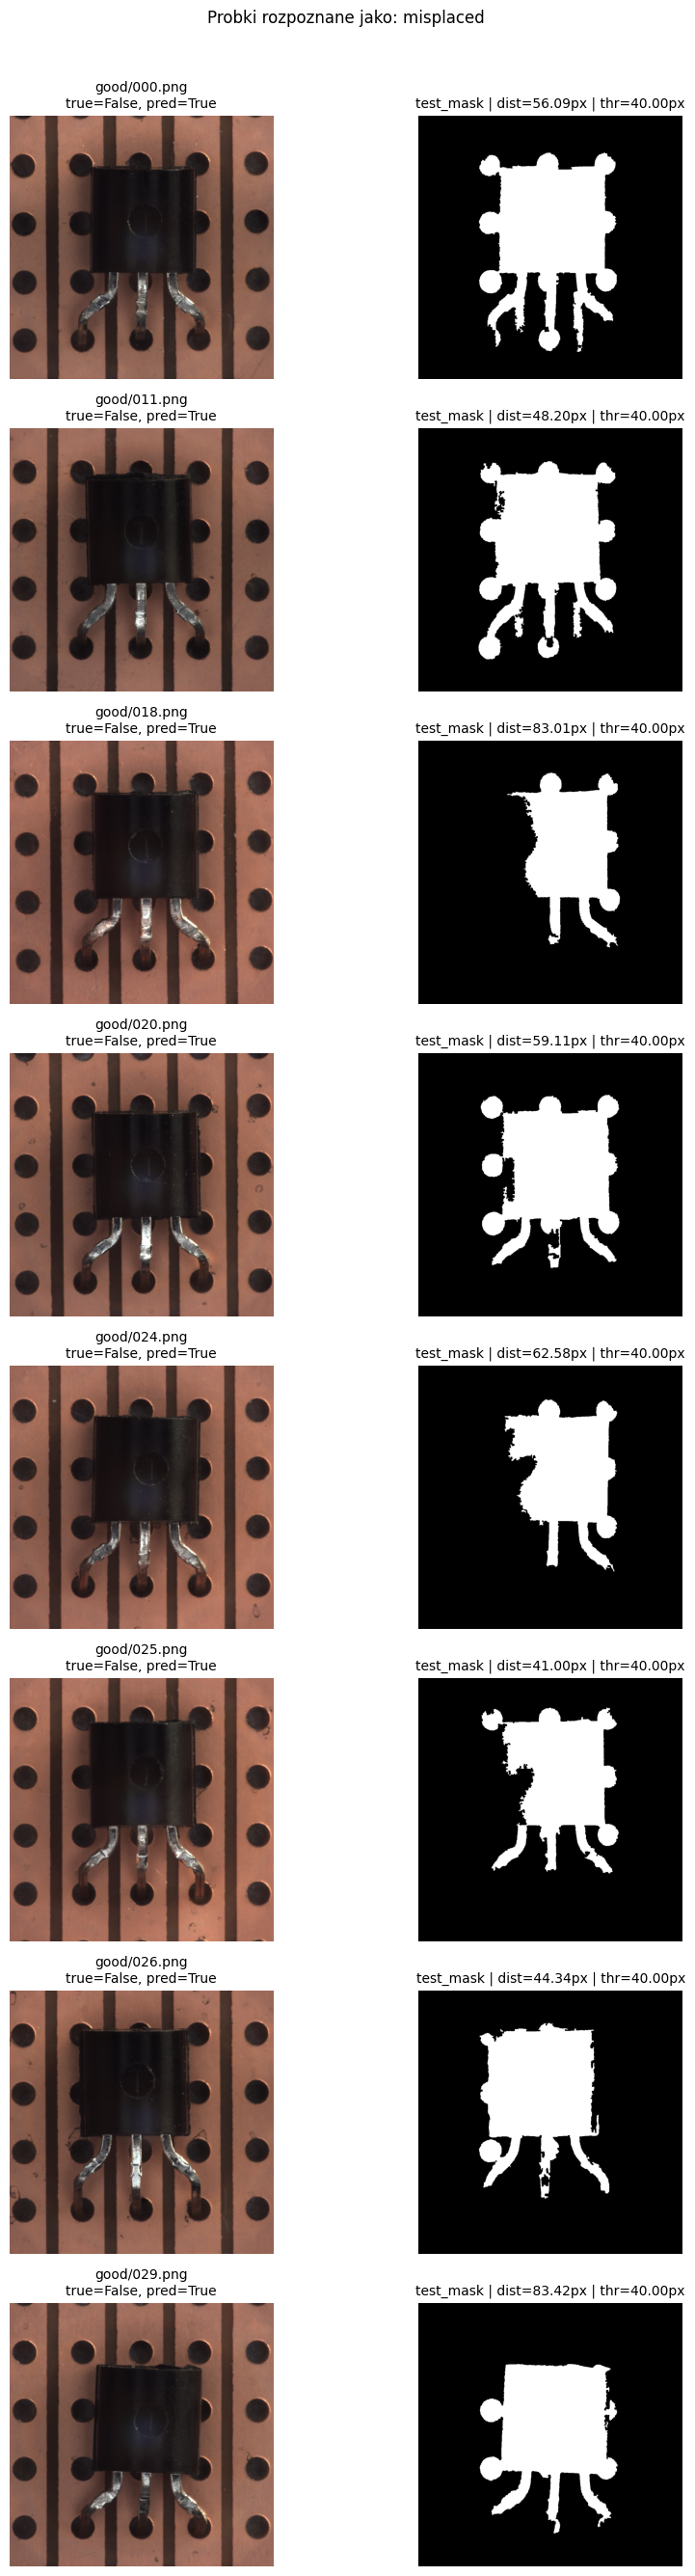


--- False Negatives ---


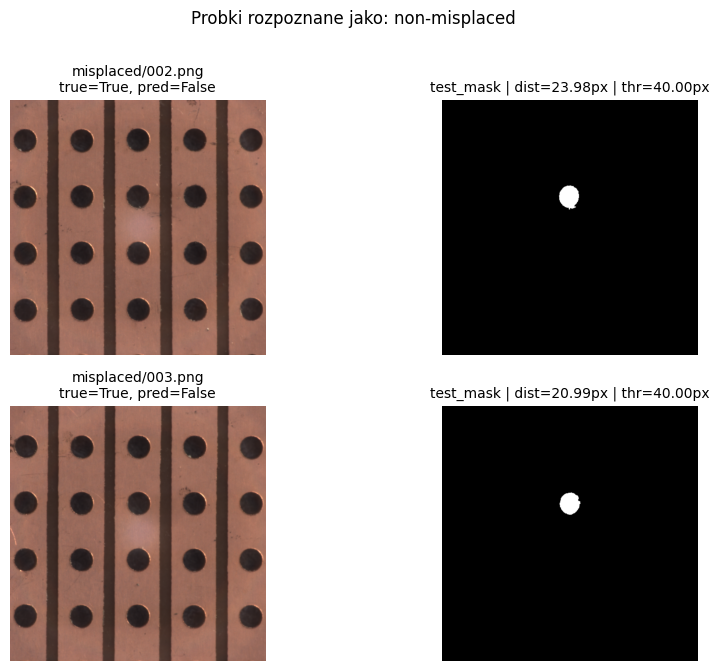

In [ ]:
def visualize_predictions(
    records: list[PredictionRecord],
    predicted_value: bool,
    max_items: int = 12,
) -> None:
    selected = [r for r in records if r.predicted_misplaced == predicted_value]
    selected = selected[:max_items]

    group_name = "misplaced" if predicted_value else "non-misplaced"
    if not selected:
        print(f"Brak probek do wyswietlenia dla grupy: {group_name}")
        return

    n = len(selected)
    fig, axes = plt.subplots(n, 2, figsize=(10, 3.3 * n))
    if n == 1:
        axes = np.array([axes])

    for i, rec in enumerate(selected):
        img = load_rgb(rec.image_path)
        pred, dbg = is_misplased(
            img,
            distance_threshold_px=rec.threshold_px,
            reference_mask=REFERENCE_MASK,
            return_debug=True,
        )

        axes[i, 0].imshow(img)
        axes[i, 0].set_title(
            f"{rec.image_path.parent.name}/{rec.image_path.name}\n"
            f"true={rec.true_misplaced}, pred={pred}"
        )
        axes[i, 0].axis("off")

        axes[i, 1].imshow(dbg["test_mask"], cmap="gray", vmin=0, vmax=255)
        axes[i, 1].set_title(
            f"test_mask | dist={dbg['distance_px']:.2f}px | thr={dbg['threshold_px']:.2f}px"
        )
        axes[i, 1].axis("off")

    plt.suptitle(f"Probki rozpoznane jako: {group_name}", y=1.01)
    plt.tight_layout()
    plt.show()


def visualize_errors(records: list[PredictionRecord], max_items: int = 8) -> None:
    fps = [r for r in records if (not r.true_misplaced) and r.predicted_misplaced][:max_items]
    fns = [r for r in records if r.true_misplaced and (not r.predicted_misplaced)][:max_items]

    print(f"False Positive: {len(fps)} | False Negative: {len(fns)}")

    if fps:
        print("\n--- False Positives ---")
        visualize_predictions(fps, predicted_value=True, max_items=max_items)
    if fns:
        print("\n--- False Negatives ---")
        visualize_predictions(fns, predicted_value=False, max_items=max_items)


visualize_predictions(records, predicted_value=True, max_items=12)
visualize_predictions(records, predicted_value=False, max_items=12)
visualize_errors(records, max_items=8)

## 8. Refactor for Reusability

In [ ]:
def run_centroid_misplaced_pipeline(
    distance_threshold_px: float,
    show_visuals: bool = True,
) -> tuple[list[PredictionRecord], dict[str, float]]:
    run_records = evaluate_test_set(distance_threshold_px=distance_threshold_px)
    run_metrics = confusion_from_records(run_records)

    print("\n=== run_centroid_misplaced_pipeline ===")
    print("Threshold:", distance_threshold_px)
    print("Metrics:", run_metrics)
    summarize_by_class(run_records)

    if show_visuals:
        visualize_predictions(run_records, predicted_value=True, max_items=10)
        visualize_predictions(run_records, predicted_value=False, max_items=10)

    return run_records, run_metrics


# Przyklad ponownego uzycia:
_ = run_centroid_misplaced_pipeline(distance_threshold_px=best_threshold, show_visuals=False)


=== run_centroid_misplaced_pipeline ===
Threshold: 40.0
Metrics: {'tp': 7.0, 'fp': 22.0, 'tn': 55.0, 'fn': 2.0, 'precision': 0.2413793103448276, 'recall': 0.7777777777777778, 'f1': 0.368421052631579, 'accuracy': 0.7209302325581395}

=== Podsumowanie per klasa ===
good         n= 50  mean_dist= 29.530  predicted_as_misplaced_rate= 0.200
bent_lead    n=  9  mean_dist= 41.218  predicted_as_misplaced_rate= 0.444
cut_lead     n=  9  mean_dist= 53.357  predicted_as_misplaced_rate= 0.556
damaged_case n=  9  mean_dist= 37.970  predicted_as_misplaced_rate= 0.333
misplaced    n=  9  mean_dist=134.867  predicted_as_misplaced_rate= 0.778
